In [2]:
import pandas as pd

df = pd.read_parquet("final_dataset.parquet")

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Find UPCs that appear in 2+ retailers
# -----------------------------------------
sku_counts = df.groupby("upc")["retailer_id"].nunique()
matched_upcs = sku_counts[sku_counts >= 2].index.tolist()

print(f"Found {len(matched_upcs)} UPCs with 2+ retailers.")

if len(matched_upcs) == 0:
    raise ValueError("No UPCs appear in 2 or more retailers.")

# Take 4–5 UPCs for screenshot
example_upcs = matched_upcs[:5]

# -----------------------------------------
# 2. Filter df and keep latest snapshot per (upc, retailer)
# -----------------------------------------
temp = df[df["upc"].isin(example_upcs)].copy()
temp["captured_at"] = pd.to_datetime(temp["captured_at"])

temp = (
    temp.sort_values("captured_at")
        .groupby(["upc", "retailer_id"], as_index=False)
        .tail(1)
)

# -----------------------------------------
# 3. Clean titles (TRUNCATE to 50 characters)
# -----------------------------------------
def truncate(text, n=50):
    if pd.isna(text):
        return ""
    return text if len(text) <= n else text[:n] + "..."

temp["title_raw"] = temp["title_raw"].apply(truncate)

# Only show date (not full timestamp)
temp["captured_date"] = temp["captured_at"].dt.date

# Final table
example_df = temp[["upc", "retailer_id", "title_raw", "price_current", "captured_date"]]
example_df = example_df.sort_values(["upc", "retailer_id"]).reset_index(drop=True)

# Pretty column labels
col_labels = ["UPC", "Retailer", "Product Title", "Price (USD)", "Capture Date"]

print(example_df)

# -----------------------------------------
# 4. Export high-quality screenshot
# -----------------------------------------
fig, ax = plt.subplots(figsize=(16, 4), dpi=350)
ax.axis("off")

table = ax.table(
    cellText=example_df.values,
    colLabels=col_labels,
    loc="center",
    cellLoc="left",
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)  # moderate row height

# Borders
for _, cell in table.get_celld().items():
    cell.set_linewidth(0.5)

plt.savefig("example_skus_clean.png", dpi=350, bbox_inches="tight", facecolor="white")
plt.close()

print("Saved: example_skus_clean.png")




Found 30 UPCs with 2+ retailers.
            upc retailer_id  \
0  190199801561        ebay   
1  190199801561     walmart   
2  194252484296        ebay   
3  194252484296     walmart   
4  194644039165        ebay   
5  194644039165     walmart   
6  194644126155        ebay   
7  194644126155     walmart   
8  194644186333        ebay   
9  194644186333     walmart   

                                           title_raw  price_current  \
0            Beats - Flex Wireless Earphones - Black          49.99   
1                                                             30.01   
2  Beats Fit Pro – True Wireless Noise Cancelling...         175.95   
3                                                            149.00   
4  Soundcore K20i Semi-in-Ear Earbuds Wireless Bl...          29.99   
5                                                             19.99   
6  Soundcore - by Anker P25i True Wireless In-Ear...          24.99   
7                                                        

In [5]:
df.groupby("upc")["retailer_id"].nunique().sort_values(ascending=False)

upc
810119071835      2
810145323182      2
194252484296      2
810119073013      2
810119072436      2
                 ..
50036405867       1
613464869696      1
617513201642      1
630130414516      1
Does not apply    1
Name: retailer_id, Length: 175, dtype: int64

In [6]:
# It will be better to see grouped by retailer because here we see that prices are generally stable.

df[["price_current", "price_prev", "discount_depth"]].describe()

,price_current,price_prev,discount_depth
count,12156.000000,11933.000000,12156.000000
mean,55.245225,55.334881,0.221237
std,59.298964,59.403521,0.281604
min,1.000000,1.000000,0.000000
25%,17.890000,17.960000,0.000000
50%,29.670000,29.690000,0.082569
75%,69.950000,69.950000,0.400020
max,299.000000,299.000000,0.914312


In [7]:
(df["price_current"] != df["price_prev"]).mean()

np.float64(0.11566304705495228)

In [8]:
## ebay shows a constant price with low and very less promotions, walmart shows lower prices
## and more promotions. Walmart has more counts because more SKU's were gathered.

gp = df.groupby("retailer_id")[["price_current", "price_prev", "discount_depth"]].describe()
gp.columns = ['_'.join(col).strip() for col in gp.columns.values]

gp

,price_current_count,price_current_mean,price_current_std,price_current_min,price_current_25%,price_current_50%,price_current_75%,price_current_max,price_prev_count,price_prev_mean,...,price_prev_75%,price_prev_max,discount_depth_count,discount_depth_mean,discount_depth_std,discount_depth_min,discount_depth_25%,discount_depth_50%,discount_depth_75%,discount_depth_max
retailer_id,,,,,,,,,,,,,,,,,,,,,
ebay,3993.0,65.759932,59.796614,7.19,20.00,47.15,84.99,249.99,3920.0,65.797727,...,84.99,249.99,3993.0,0.031739,0.089496,0.0,0.0,0.000000,0.000000,0.571510
walmart,8163.0,50.101868,58.371785,1.00,16.99,24.88,59.00,299.00,8013.0,50.216405,...,59.00,299.00,8163.0,0.313931,0.296678,0.0,0.0,0.256835,0.500125,0.914312


In [9]:
df[df["price_current"] != df["price_prev"]]["promo_flag"].mean()

np.float64(0.6266002844950214)

In [9]:
df.columns

Index(['captured_at', 'retailer_id', 'native_item_id', 'upc', 'title_raw',
       'brand_raw', 'model_raw', 'category_raw_path', 'product_url',
       'currency', 'price_current', 'price_regular', 'msrp',
       'price_regular_chosen', 'regular_price_source', 'shipping_cost',
       'landed_price', 'promo_flag', 'promo_detect_method', 'discount_depth',
       'in_stock_flag', 'availability_message', 'rating_avg', 'rating_count',
       'source_endpoint', 'ingest_run_id', 'ingest_status', 'price_prev',
       'price_change', 'price_change_pct', 'roll_min_30', 'roll_max_30',
       'roll_vol_30', 'stockout_rate_30', 'price_vs_msrp_pct'],
      dtype='object')

In [10]:
## The data has captured a lot of promotions and mostly are from walmart, and the percentage of on promotion
## items for walmart is higher than items that are not on promotion. and it is the total opposite for ebay.

df.groupby("retailer_id")["promo_flag"].value_counts()

retailer_id  promo_flag
ebay         False         3393
             True           600
walmart      True          5750
             False         2413
Name: count, dtype: int64

In [ ]:
## PRICE VOLATILITY FEATURES

In [11]:
df['price_return'] = (df.price_current-df.price_prev)/df.price_prev
df['price_range_metric'] = (df.roll_max_30-df.roll_min_30)/df.price_current
df['cv_price'] = df.price_current/df.price_current.mean()

In [ ]:
## PRICE CHANGE BEHAVIOR

In [18]:
## Price Change Frequency (per SKU)
change_freq = df.groupby(["retailer_id","native_item_id"])["price_change"].mean()

## Rigidity / Price Stickiness: Median number of days the price stays unchanged
df['no_change'] = (df.price_change == 0).astype(int)

## Avg Absolute Change Size
df['abs_change_pct'] = df['price_change_pct'].abs()


In [ ]:
## PROMO & DISCOUNT PATTERNS

In [12]:
## Promo Depth (SKU-level avg)
promo_depth = df[df.promo_flag == 1].groupby(['retailer_id','native_item_id'])['discount_depth'].mean()

## Promo Breadth (Retailer-wide daily %)
daily_breadth = df.groupby(['retailer_id','captured_at'])['promo_flag'].mean()

## Promo Intensity (% of days in promo for a SKU)
promo_intensity = df.groupby(['retailer_id','native_item_id'])['promo_flag'].mean()

## Promo Volatility (day-to-day variation)
promo_volatility = daily_breadth.groupby('retailer_id').std()

## Discount Range
discount_range = df.groupby(['retailer_id','native_item_id'])['discount_depth'].max() - \
                  df.groupby(['retailer_id','native_item_id'])['discount_depth'].min()

In [ ]:
## PRICE POSITIONING FEATURES

In [13]:
## Relative Markdown Ratio
df['markdown_ratio'] = df['price_regular'] / df['msrp']

## EDLP Consistency Metric: Low variation between price_regular and price_current.
df['edlp_consistency'] = 1 - (df.price_regular - df.price_current).abs() / df.price_regular


In [ ]:
## Inventory Stock Sensitivity

In [14]:
## % Time In-Stock: Dynamic retailers often drop prices before stockouts.
in_stock_rate = df.groupby(['retailer_id','native_item_id'])['in_stock_flag'].mean()

## Price–Stock Interaction
corr_price_stock = (
    df.groupby(['retailer_id','native_item_id'])
      .apply(lambda g: g['price_current'].corr(g['in_stock_flag']))
      .reset_index(name='corr_price_stock')
)

## Max Discount Spike
df['discount_spike'] = (
    df.groupby(['retailer_id','native_item_id'])['discount_depth']
      .transform(lambda x: x.quantile(0.95))
)

## Weekend Promo Rate
df['is_weekend'] = df['captured_at'].dt.dayofweek >= 5
weekend_promo_rate = df.groupby('retailer_id')['promo_flag'].mean()



/var/folders/np/4597lfcs6d997yx62m5k2vfc0000gn/T/ipykernel_1582/2465521942.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g['price_current'].corr(g['in_stock_flag']))


In [ ]:
## SEASONALITY / EXTREME PROMO SIGNALS

In [15]:
## Max Discount Spike
df['discount_spike'] = (
    df.groupby(['retailer_id','native_item_id'])['discount_depth']
      .transform(lambda x: x.quantile(0.95))
)


## Weekend Promo Rate
df['is_weekend'] = df['captured_at'].dt.dayofweek >= 5
weekend_promo_rate = df.groupby('retailer_id')['promo_flag'].mean()

In [16]:
## DISTRIBUTIONAL FEATURES (Dynamic sellers have richer price distributions)

## Number of Unique Prices per SKU
unique_prices = df.groupby(['retailer_id','native_item_id'])['price_current'].nunique()


In [19]:
## Aggregated level features

g = df.groupby(['retailer_id', 'native_item_id'])

roll_vol_30_sku        = g['roll_vol_30'].mean()
edlp_consistency_sku   = g['edlp_consistency'].mean()
rigidity_sku           = g['no_change'].mean()
price_range_metric_sku = g['price_range_metric'].mean()
price_return_sku       = g['price_return'].mean()
abs_change_pct_sku     = g['abs_change_pct'].mean()
price_vs_msrp_pct_sku  = g['price_vs_msrp_pct'].mean()
stockout_rate_30_sku   = g['stockout_rate_30'].mean()
discount_spike         = g['discount_depth'].quantile(0.95)

promo_volatility_sku   = g['promo_flag'].std()      # <-- see 1 above
corr_price_stock       = (
    g.apply(lambda gg: gg['price_current'].corr(gg['in_stock_flag']))
     .rename('corr_price_stock')
)

# change_freq, discount_range, unique_prices, in_stock_rate
# should already be SKU-level Series with the same MultiIndex.

sku_features = pd.concat(
    [
        change_freq.rename('change_freq'),
        roll_vol_30_sku.rename('roll_vol_30'),
        discount_range.rename('discount_range'),
        promo_volatility_sku.rename('promo_volatility'),
        unique_prices.rename('unique_prices'),
        edlp_consistency_sku.rename('edlp_consistency'),
        rigidity_sku.rename('rigidity'),
        price_range_metric_sku.rename('price_range_metric'),
        price_return_sku.rename('price_return'),
        abs_change_pct_sku.rename('abs_change_pct'),
        in_stock_rate.rename('in_stock_rate'),
        corr_price_stock,                              # already named
        price_vs_msrp_pct_sku.rename('price_vs_msrp_pct'),
        stockout_rate_30_sku.rename('stockout_rate_30'),
        discount_spike.rename('discount_spike'),
    ],
    axis=1
)

# Optional: bring retailer & SKU back as columns
sku_features = sku_features.reset_index()

/var/folders/np/4597lfcs6d997yx62m5k2vfc0000gn/T/ipykernel_1582/200341239.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g.apply(lambda gg: gg['price_current'].corr(gg['in_stock_flag']))


In [20]:
sku_features.columns

Index(['retailer_id', 'native_item_id', 'change_freq', 'roll_vol_30',
       'discount_range', 'promo_volatility', 'unique_prices',
       'edlp_consistency', 'rigidity', 'price_range_metric', 'price_return',
       'abs_change_pct', 'in_stock_rate', 'corr_price_stock',
       'price_vs_msrp_pct', 'stockout_rate_30', 'discount_spike'],
      dtype='object')

In [21]:
from sklearn.preprocessing import StandardScaler



In [22]:
# Features where higher = more Dynamic behaviour
dynamic_cols = [
    "change_freq",
    "roll_vol_30",
    "discount_range",
    "promo_volatility",
    "unique_prices",
]

# EDLP-friendly features where higher is already "good" (stable)
edlp_base_cols = [
    "edlp_consistency",
    "rigidity",
    "in_stock_rate",
]

# Dynamic-type features we also want to treat as "bad for EDLP"
# (we'll invert them for the EDLP score)
edlp_inv_source_cols = [
    "change_freq",
    "roll_vol_30",
    "discount_range",
    "promo_volatility",
]


In [23]:
for c in edlp_inv_source_cols:
    sku_features[c + "_inv"] = -sku_features[c]

edlp_all_cols = edlp_base_cols + [c + "_inv" for c in edlp_inv_source_cols]


In [24]:
cols_to_scale = dynamic_cols + edlp_all_cols

scaler = StandardScaler()
scaled_vals = scaler.fit_transform(sku_features[cols_to_scale])

# Add z-scored versions with `_z` suffix
sku_features[[c + "_z" for c in cols_to_scale]] = scaled_vals


/Users/muhammadmoiz/Documents/UoP/MSBA 286/repo/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/Users/muhammadmoiz/Documents/UoP/MSBA 286/repo/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/Users/muhammadmoiz/Documents/UoP/MSBA 286/repo/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [25]:
# Dynamic score: average z-score of dynamic features
sku_features["dynamic_score"] = sku_features[[c + "_z" for c in dynamic_cols]].mean(axis=1)

# EDLP score: average z-score of EDLP-friendly features (including inverses)
sku_features["edlp_score"] = sku_features[[c + "_z" for c in edlp_all_cols]].mean(axis=1)


In [26]:
retailer_scores = (
    sku_features
    .groupby("retailer_id")[["dynamic_score", "edlp_score"]]
    .median()        # median is robust to outliers
)


In [27]:
def classify(row, margin=0.3):
    if row["dynamic_score"] > row["edlp_score"] + margin:
        return "Dynamic"
    if row["edlp_score"] > row["dynamic_score"] + margin:
        return "EDLP"
    return "Hybrid"

retailer_scores["strategy"] = retailer_scores.apply(classify, axis=1)


In [28]:
print(retailer_scores)

             dynamic_score  edlp_score strategy
retailer_id                                    
ebay             -0.527378    0.554166     EDLP
walmart           0.005862   -0.097184   Hybrid


In [28]:
demand_base.columns


NameError: name 'demand_base' is not defined

NameError: name 'demand_base' is not defined

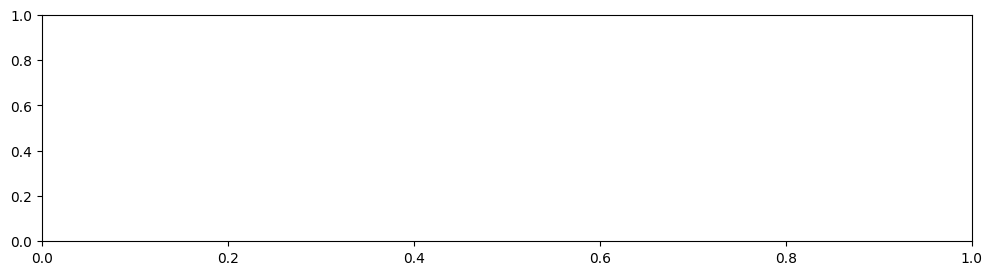

In [29]:
import matplotlib.pyplot as plt

features = ["rigidity", "promo_intensity", "avg_discount_depth", "price_vol"]

plt.figure(figsize=(12, 10))

for i, f in enumerate(features, 1):
    plt.subplot(3, 1, i)

    # Extract for each retailer
    walmart_vals = demand_base.loc["walmart"][f]
    ebay_vals = demand_base.loc["ebay"][f]

    plt.boxplot([walmart_vals, ebay_vals], labels=["Walmart", "eBay"])
    plt.title(f"Boxplot of {f.replace('_',' ').title()} by Retailer")
    plt.ylabel(f.replace('_',' ').title())
    plt.grid(axis='y', linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


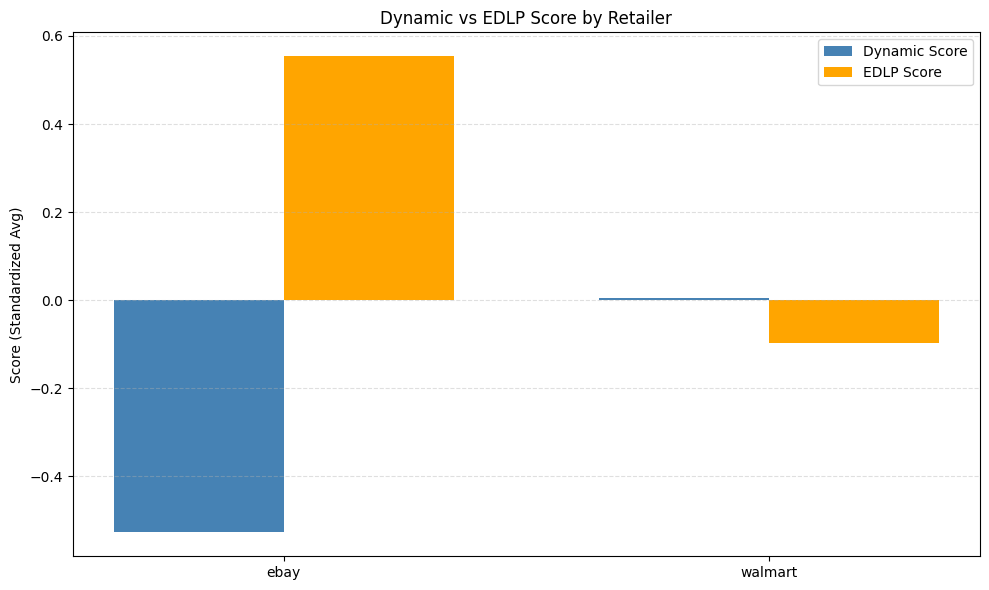

In [250]:
import numpy as np
scores = retailer_scores[["dynamic_score","edlp_score"]]
retailers = retailer_scores.index.tolist()

x = np.arange(len(retailers))
width = 0.35

# Plot
plt.figure(figsize=(10,6))

plt.bar(x - width/2, scores['dynamic_score'], width, label='Dynamic Score', color='steelblue')
plt.bar(x + width/2, scores['edlp_score'], width, label='EDLP Score', color='orange')

# Labels and formatting
plt.xticks(x, retailers)
plt.ylabel("Score (Standardized Avg)")
plt.title("Dynamic vs EDLP Score by Retailer")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
## BUULDING THE DEMAND STRENGHT MODEL

In [30]:
## Promo Intensity
promo_intensity = g["promo_flag"].mean()

## Average Discount Depth
avg_discount_depth = g["discount_depth"].mean()

## Price Volatility
price_vol = g["roll_vol_30"].mean()

## Pricing Power (Price vs MSRP): Higher = better demand strength.
mean_price_vs_msrp = g["price_vs_msrp_pct"].mean()

## Price Rigidity / EDLP stability
rigidity = g["no_change"].mean()
edlp_consistency = g["edlp_consistency"].mean()

## SKU Level Dataframe

demand_base = pd.DataFrame({
    "promo_intensity": promo_intensity,
    "avg_discount_depth": avg_discount_depth,
    "price_vol": price_vol,
    "mean_price_vs_msrp": mean_price_vs_msrp,
    "rigidity": rigidity,
    "edlp_consistency": edlp_consistency
})

demand_base.head()


promo_intensity  avg_discount_depth  \
retailer_id native_item_id                                                      
ebay        v1|112358941238|412775517839         0.000000            0.000000   
            v1|116390435229|0                    0.000000            0.000000   
            v1|116746209631|0                    0.000000            0.000000   
            v1|135564241444|0                    0.763636            0.152897   
            v1|145917048227|0                    0.000000            0.000000   

                                          price_vol  mean_price_vs_msrp  \
retailer_id native_item_id                                                
ebay        v1|112358941238|412775517839   0.000000                 NaN   
            v1|116390435229|0              0.000000                 NaN   
            v1|116746209631|0              0.000000                 NaN   
            v1|135564241444|0              0.127503                 NaN   
            v1|145917048227|0              0.000000                 NaN   

                                          rigidity  edlp_consistency  
retailer_id native_item_id                                            
ebay        v1|112358941238|412775517839  0.981818               NaN  
            v1|116390435229|0             0.981818               NaN  
            v1|116746209631|0             0.981818               NaN  
            v1|135564241444|0             0.709091          0.799778  
            v1|145917048227|0             0.981818               NaN

In [31]:
## Normalize the features
scaler = StandardScaler()
Z = scaler.fit_transform(demand_base)

Z = pd.DataFrame(Z, index=demand_base.index, columns=demand_base.columns)

## Constructing the Demand Strength Index (DSI)
demand_base["demand_strength"] = (
      (- Z['promo_intensity'])        * 0.25
    + (- Z['avg_discount_depth'])     * 0.20
    + (- Z['price_vol'])              * 0.10
    + (  Z['mean_price_vs_msrp'])     * 0.25
    + (  Z['rigidity'])               * 0.10
    + (  Z['edlp_consistency'])       * 0.10
)

demand_base.sort_values("demand_strength", ascending=False).head(10)


promo_intensity  avg_discount_depth  price_vol  \
retailer_id native_item_id                                                   
walmart     233758219              0.000000            0.000000   0.000000   
            482493465              0.000000            0.000000   0.000000   
            416099849              0.000000            0.000000   0.003783   
            252575372              0.000000            0.000000   0.000000   
            55509211               0.000000            0.000000   0.000000   
            479338409              0.000000            0.000000   0.000000   
            13895355965            0.018182            0.012999   0.010977   
            248390097              0.018182            0.005872   0.094288   
            3752378948             0.090909            0.010866   0.014082   
            1546280223             0.109091            0.015859   0.045947   

                            mean_price_vs_msrp  rigidity  edlp_consistency  \
retailer_id native_item_id                                                   
walmart     233758219                 1.254024  0.981818          0.745976   
            482493465                 1.053823  0.981818          0.946177   
            416099849                 1.059575  0.963636          0.940425   
            252575372                 1.005030  0.981818          0.994970   
            55509211                  1.000000  0.981818          1.000000   
            479338409                 0.992662  0.981818          0.992662   
            13895355965               1.002597  0.945455          0.971406   
            248390097                 1.101222  0.945455          0.887034   
            3752378948                0.940238  0.927273          0.940238   
            1546280223                0.984141  0.909091          0.984141   

                            demand_strength  
retailer_id native_item_id                   
walmart     233758219              1.179335  
            482493465              1.080430  
            416099849              1.063390  
            252575372              1.056325  
            55509211               1.053840  
            479338409              1.044284  
            13895355965            0.980220  
            248390097              0.931136  
            3752378948             0.852364  
            1546280223             0.838759

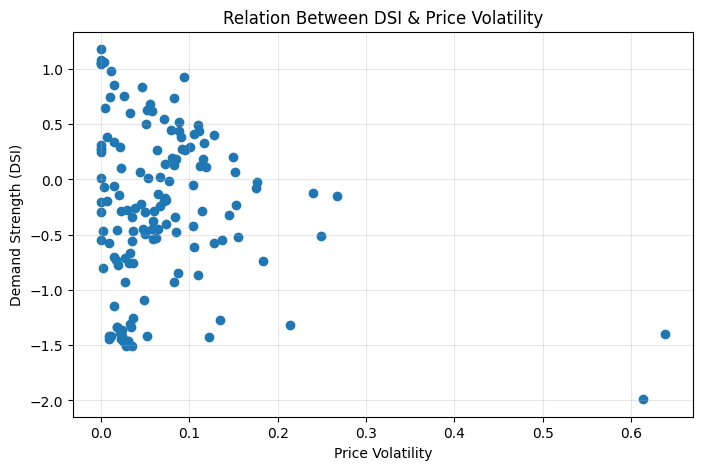

In [260]:
plt.figure(figsize=(8,5))
plt.scatter(x=demand_base["price_vol"],y=demand_base["demand_strength"])
plt.title("Relation Between DSI & Price Volatility")
plt.xlabel("Price Volatility")
plt.ylabel("Demand Strength (DSI)")
plt.grid(alpha=0.3)
plt.show()

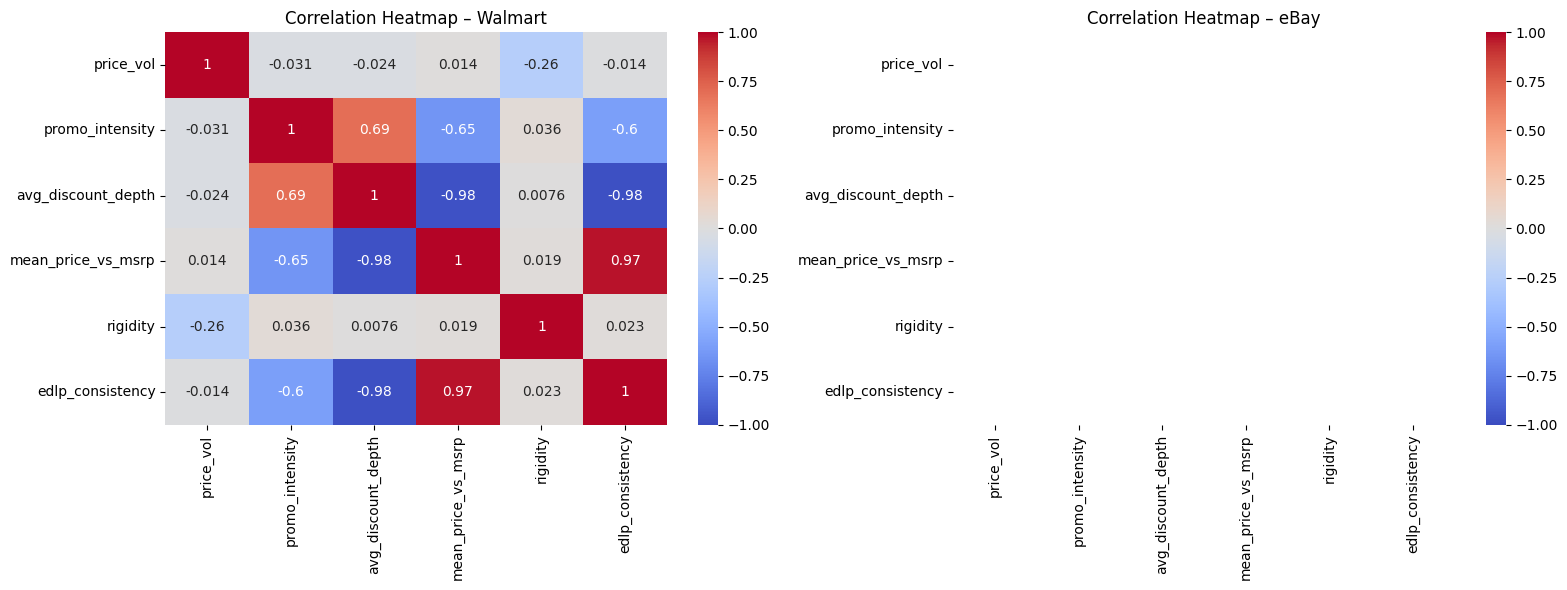

In [247]:
# Filter retailers
walmart_df = demand_base.loc["walmart"]
ebay_df    = demand_base.loc["ebay"]

# Select only numeric columns
numeric_cols = [
    "price_vol", "promo_intensity", "avg_discount_depth",
    "mean_price_vs_msrp", "rigidity", "edlp_consistency",
]

walmart_num = walmart_df[numeric_cols].dropna()
ebay_num    = ebay_df[numeric_cols].dropna()

corr_walmart = walmart_num.corr()
corr_ebay    = ebay_num.corr()


plt.figure(figsize=(16, 6))

# Walmart heatmap
plt.subplot(1, 2, 1)
sns.heatmap(corr_walmart, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap – Walmart")

# eBay heatmap
plt.subplot(1, 2, 2)
sns.heatmap(corr_ebay, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap – eBay")

plt.tight_layout()
plt.show()


In [244]:
demand_base.columns

Index(['promo_intensity', 'avg_discount_depth', 'price_vol',
       'mean_price_vs_msrp', 'rigidity', 'edlp_consistency',
       'demand_strength'],
      dtype='object')

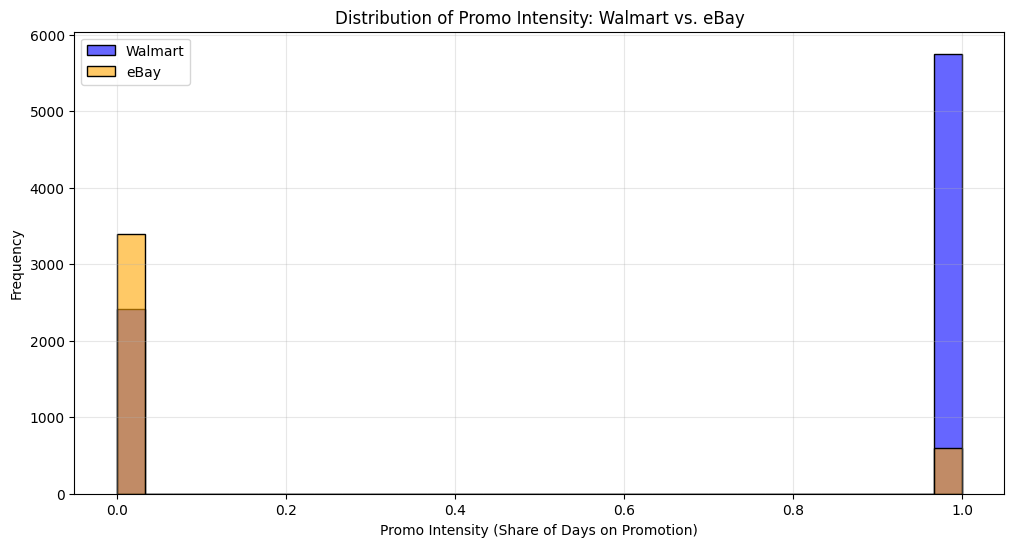

In [235]:
plt.figure(figsize=(12,6))

sns.histplot(
    df.query("retailer_id=='walmart'")["promo_flag"],
    bins=30, color="blue", label="Walmart", alpha=0.6
)

sns.histplot(
    df.query("retailer_id=='ebay'")["promo_flag"],
    bins=30, color="orange", label="eBay", alpha=0.6
)

plt.title("Distribution of Promo Intensity: Walmart vs. eBay")
plt.xlabel("Promo Intensity (Share of Days on Promotion)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


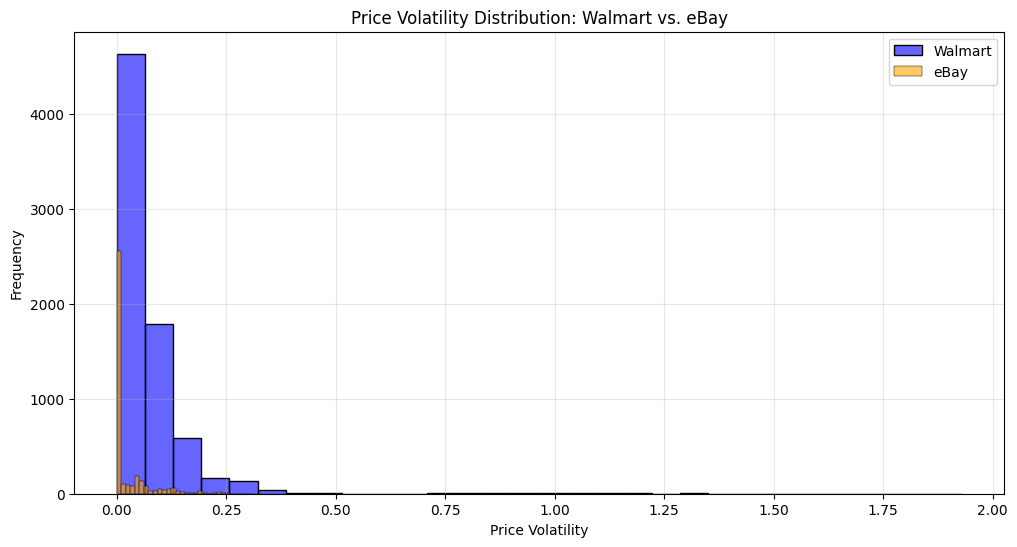

In [234]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.histplot(df.query("retailer_id=='walmart'")["roll_vol_30"],
             color="blue", label="Walmart", bins=30, kde=False, alpha=0.6)

sns.histplot(df.query("retailer_id=='ebay'")["roll_vol_30"],
             color="orange", label="eBay", bins=30, kde=False, alpha=0.6)

plt.title("Price Volatility Distribution: Walmart vs. eBay")
plt.xlabel("Price Volatility")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

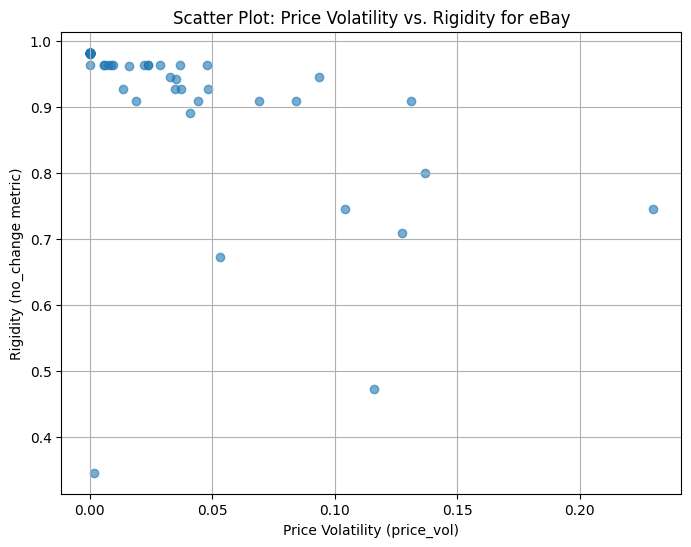

In [230]:
dem_ebay = demand_base.query("retailer_id=='ebay'")
plt.figure(figsize=(8,6))
plt.scatter(dem_ebay["price_vol"], dem_ebay["rigidity"], alpha=0.6)

plt.title("Scatter Plot: Price Volatility vs. Rigidity for eBay")
plt.xlabel("Price Volatility (price_vol)")
plt.ylabel("Rigidity (no_change metric)")
plt.grid(True)
plt.show()


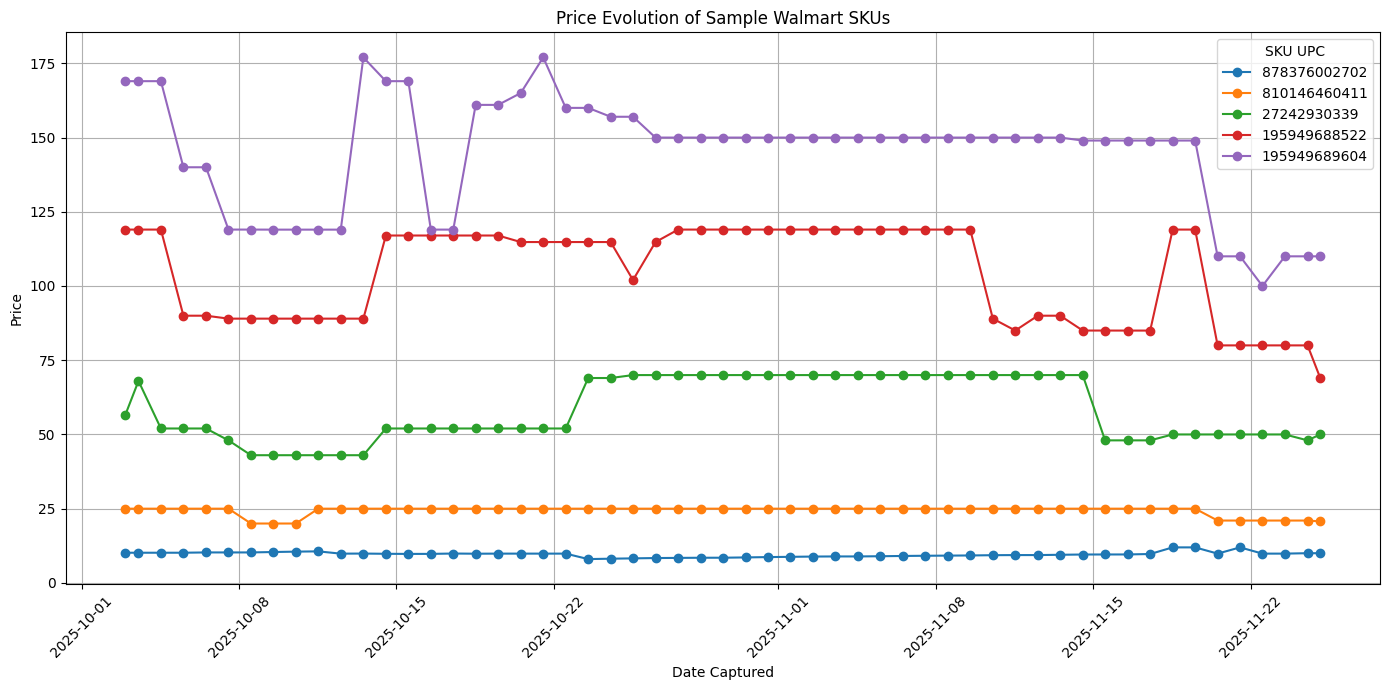

In [209]:
sample_skus = df.query("retailer_id=='walmart'")["upc"].unique()[:5]

plt.figure(figsize=(14,7))

for sku in sample_skus:
    sku_df = df.query("retailer_id=='walmart' and upc==@sku").sort_values("captured_at")
    plt.plot(sku_df["captured_at"], sku_df["price_current"], marker="o", label=sku)

plt.title("Price Evolution of Sample Walmart SKUs")
plt.xlabel("Date Captured")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend(title="SKU UPC")
plt.grid(True)

plt.tight_layout()
plt.show()

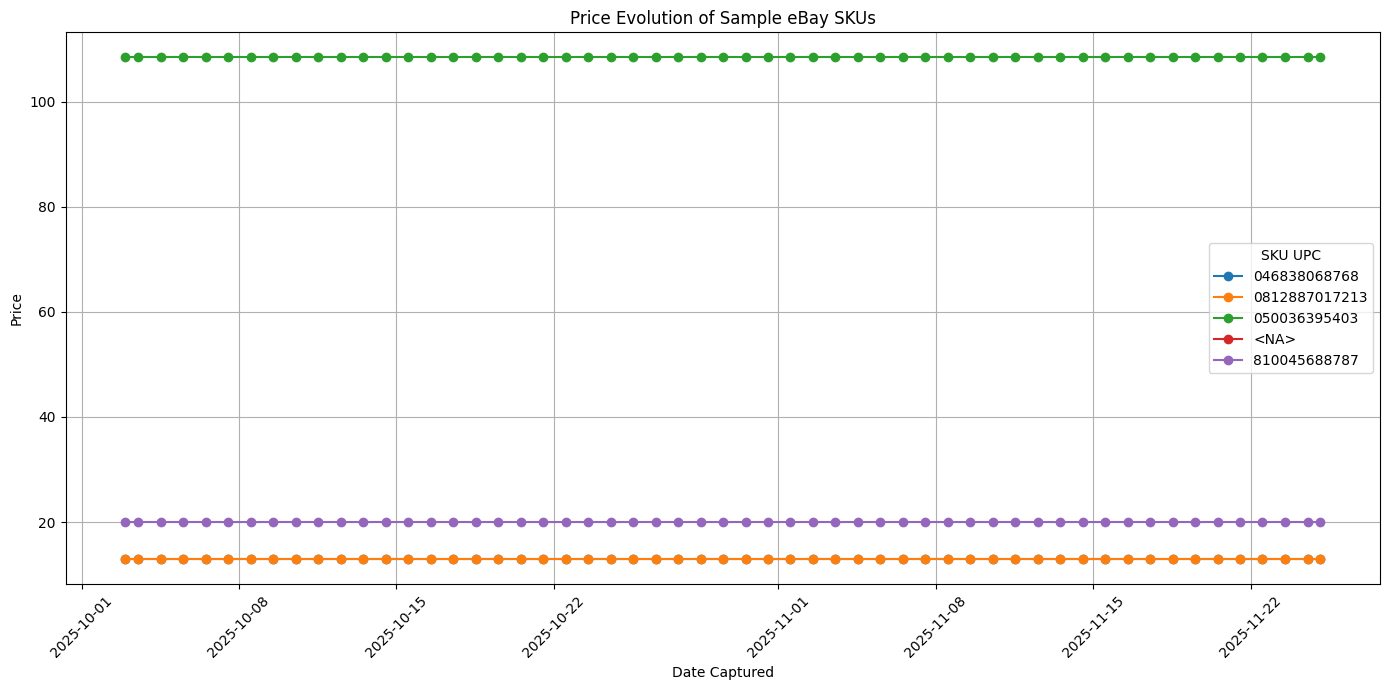

In [221]:
sample_skus_ebay = df.query("retailer_id=='ebay'")["upc"].unique()[:5]

plt.figure(figsize=(14,7))

for sku in sample_skus_ebay:
    sku_df = df.query("retailer_id=='ebay' and upc==@sku").sort_values("captured_at")
    plt.plot(sku_df["captured_at"], sku_df["price_current"], marker="o", label=sku)

plt.title("Price Evolution of Sample eBay SKUs")
plt.xlabel("Date Captured")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend(title="SKU UPC")
plt.grid(True)

plt.tight_layout()
plt.show()

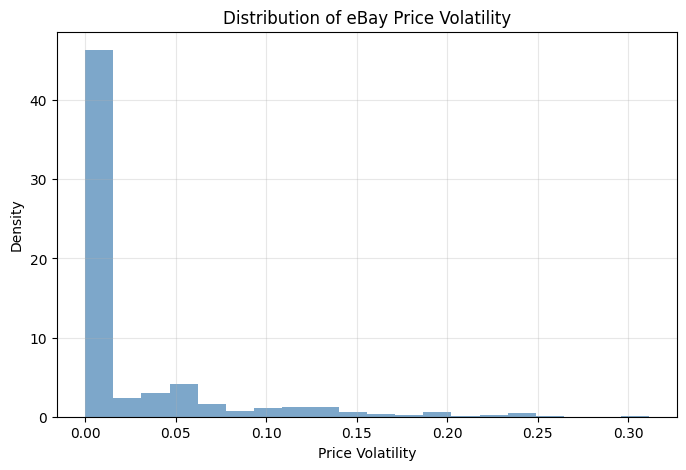

In [219]:
plt.figure(figsize=(8,5))
plt.hist(ebay_id["roll_vol_30"],bins=20,density=True,alpha=0.7, color="steelblue")
plt.title("Distribution of eBay Price Volatility")
plt.xlabel("Price Volatility")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()

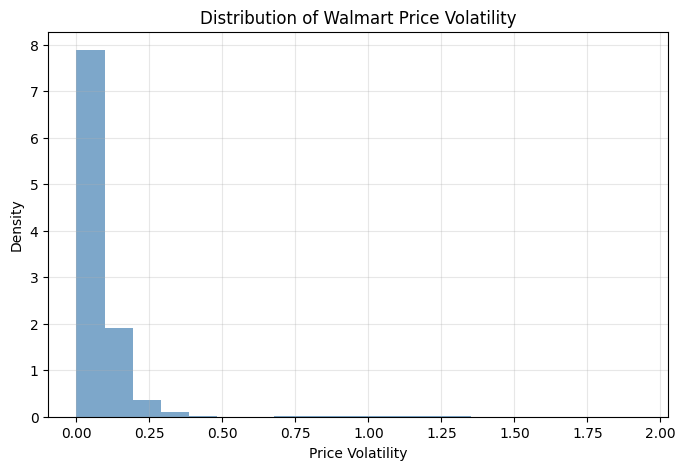

In [220]:
wm_id = df.query("retailer_id=='walmart'")
plt.figure(figsize=(8,5))
plt.hist(wm_id["roll_vol_30"],bins=20,density=True,alpha=0.7, color="steelblue")
plt.title("Distribution of Walmart Price Volatility")
plt.xlabel("Price Volatility")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()

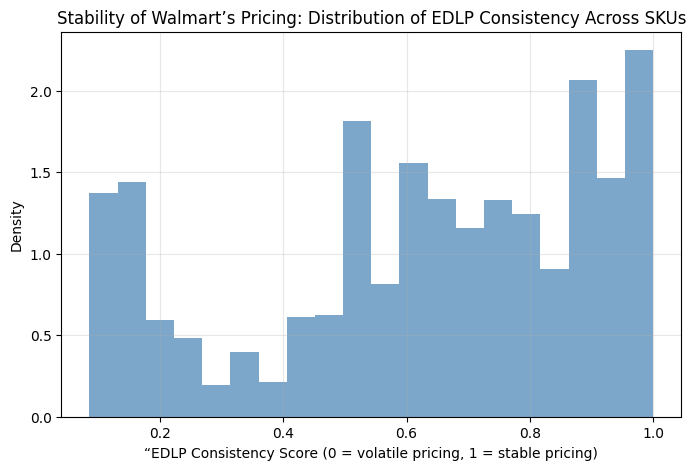

In [213]:
plt.figure(figsize=(8,5))
plt.hist(wm_msrp["edlp_consistency"],bins=20,density=True,alpha=0.7, color="steelblue")
plt.title("Stability of Walmart’s Pricing: Distribution of EDLP Consistency Across SKUs")
plt.xlabel("“EDLP Consistency Score (0 = volatile pricing, 1 = stable pricing)")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()

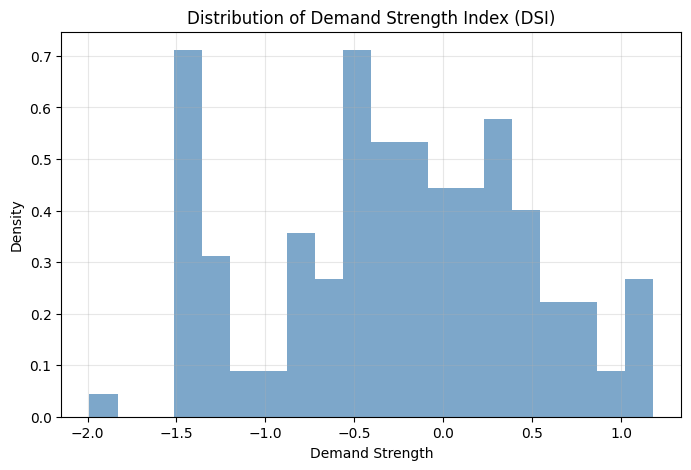

In [181]:
plt.figure(figsize=(8,5))
plt.hist(demand_base["demand_strength"], bins=20, density=True, alpha=0.7, color="steelblue")
plt.title("Distribution of Demand Strength Index (DSI)")
plt.xlabel("Demand Strength")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()

In [32]:
## Merging to SKU level data

sku_meta = df.groupby(["retailer_id", "native_item_id"]).agg({
    "price_current": "mean",
    "price_vs_msrp_pct": "mean",
    "roll_vol_30": "mean",
    "price_range_metric": "mean",
    "promo_flag": "mean",
    "discount_depth": "mean",
    "no_change": "mean",
    "edlp_consistency": "mean",
    "stockout_rate_30": "mean"
}).rename(columns={
    "price_current": "mean_price",
    "price_vs_msrp_pct": "mean_price_vs_msrp",
    "roll_vol_30": "price_vol",
    "promo_flag": "promo_intensity",
    "discount_depth": "avg_discount_depth",
    "no_change": "rigidity"
})

model_df = sku_meta.merge(
    demand_base[["demand_strength"]],
    left_index=True,
    right_index=True,
    how="inner"
)

In [33]:
model_df = model_df.fillna(model_df.median())

model_df.head()
model_df.isna().sum()

mean_price              0
mean_price_vs_msrp      0
price_vol               0
price_range_metric      0
promo_intensity         0
avg_discount_depth      0
rigidity                0
edlp_consistency        0
stockout_rate_30      223
demand_strength         0
dtype: int64

In [34]:
model_df = model_df.drop(columns=["stockout_rate_30"])

model_df.head()
model_df.isna().sum()

mean_price            0
mean_price_vs_msrp    0
price_vol             0
price_range_metric    0
promo_intensity       0
avg_discount_depth    0
rigidity              0
edlp_consistency      0
demand_strength       0
dtype: int64

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = model_df.drop(columns=["demand_strength"])
y = model_df["demand_strength"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)




,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
from sklearn.metrics import r2_score

pred = rf.predict(X_test)
print("R²:", r2_score(y_test, pred))


R²: 0.9634787795669073


In [37]:
import pandas as pd

fi = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(fi)


              feature  importance
1  mean_price_vs_msrp    0.674683
5  avg_discount_depth    0.185977
7    edlp_consistency    0.076968
4     promo_intensity    0.036241
6            rigidity    0.009692
3  price_range_metric    0.006616
2           price_vol    0.006045
0          mean_price    0.003778


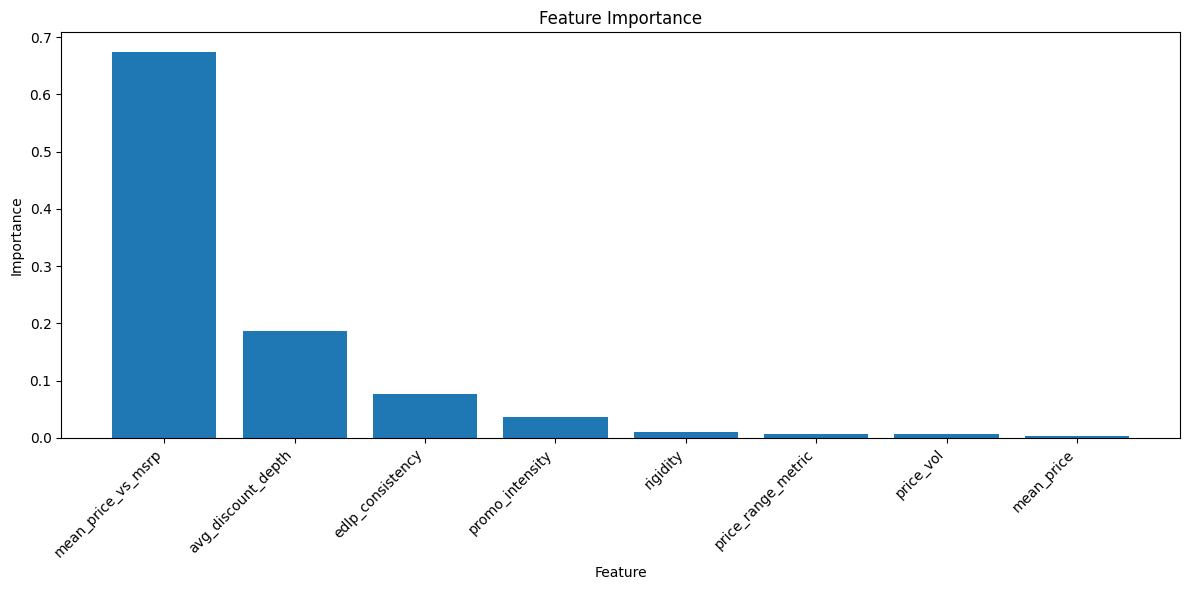

In [38]:
plt.figure(figsize=(12,6))
plt.bar(fi["feature"], fi["importance"])

plt.title("Feature Importance")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()

In [39]:
## Simulation 1 — What happens if discount depth increases by X%?

simulate = X_test.copy()
simulate["avg_discount_depth"] += 0.05    # +5% deeper promos

predicted = rf.predict(simulate)
print(predicted)

[-0.23475569 -1.36956009 -1.06958204 -1.37000553 -0.34686761 -1.39286882
 -0.23998659 -0.08757402 -0.19853327 -0.29859715 -0.23734609 -0.23475569
 -0.28234971 -0.23416529 -0.23475569 -0.23475569  0.11316412 -0.48096376
 -0.16622242 -0.04248612  0.38735708 -0.25725362 -0.42950999  0.05143598
 -0.55274829 -0.13123431 -0.16987507 -0.27843392 -0.23476291 -0.51940688
  0.04739143 -0.23331997 -0.23475569 -0.23475569 -1.27862294 -1.3454719
  0.82772425 -1.44235462  0.13351874 -1.27742516 -0.50214585 -0.74935693
  0.56188559 -1.47759188 -0.87575129]


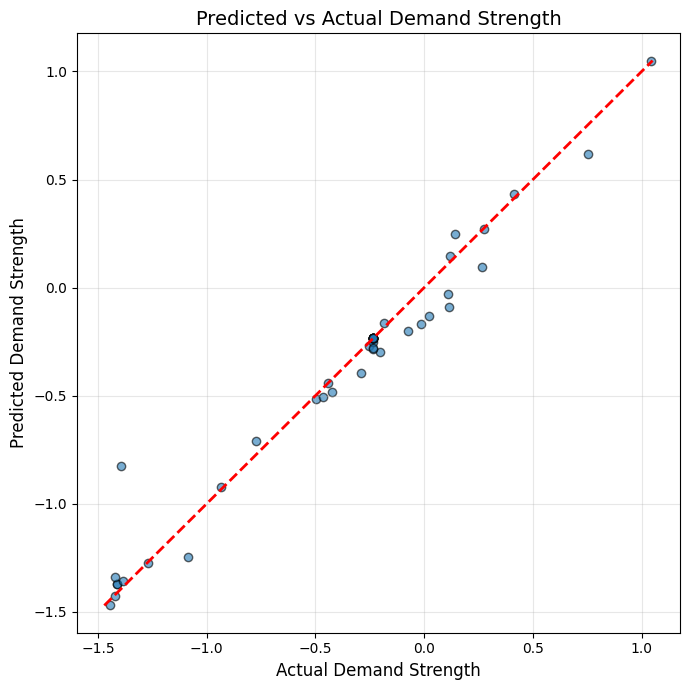

In [261]:

# y_test = actual demand_strength
# pred   = model predictions (from rf.predict(X_test))

plt.figure(figsize=(7, 7))

plt.scatter(y_test, pred, alpha=0.6, edgecolor='k')

# 45-degree reference line (perfect predictions)
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual Demand Strength", fontsize=12)
plt.ylabel("Predicted Demand Strength", fontsize=12)
plt.title("Predicted vs Actual Demand Strength", fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


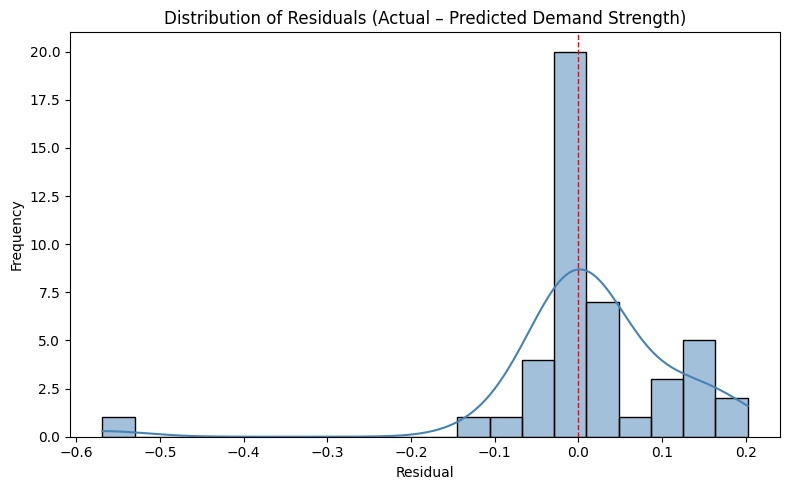

In [262]:
# Compute residuals
residuals = y_test - pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=20, kde=True, color='steelblue')

plt.title("Distribution of Residuals (Actual – Predicted Demand Strength)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.axvline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


In [40]:
base_pred = rf.predict(X_test)
new_pred = rf.predict(simulate)

delta = new_pred - base_pred
print("Average effect of +5% discount:", delta.mean())


Average effect of +5% discount: -0.029285784532312013


In [41]:
model_df.columns

Index(['mean_price', 'mean_price_vs_msrp', 'price_vol', 'price_range_metric',
       'promo_intensity', 'avg_discount_depth', 'rigidity', 'edlp_consistency',
       'demand_strength'],
      dtype='object')

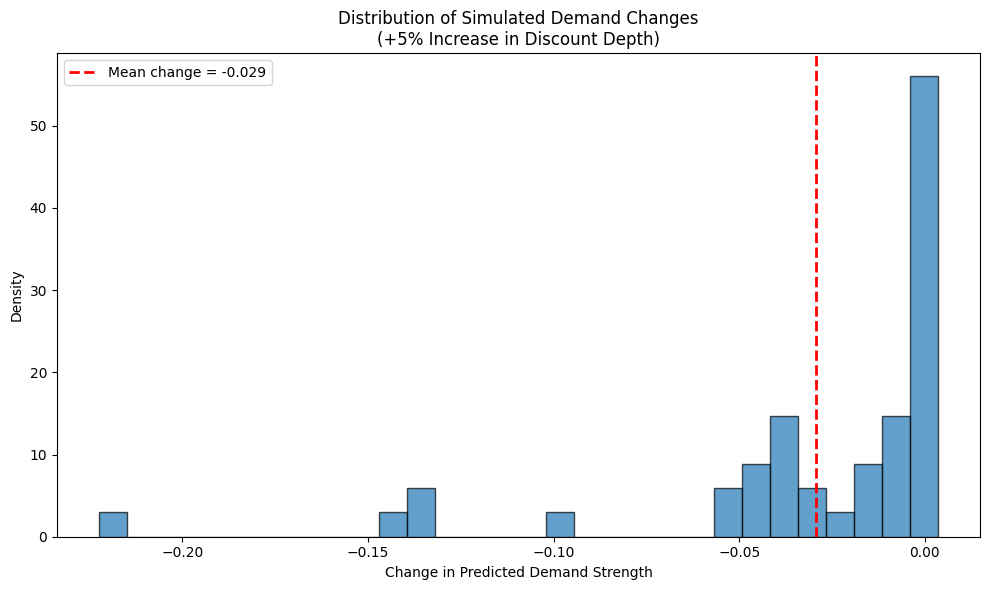

In [43]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))
plt.hist(delta, bins=30, density=True, alpha=0.7, edgecolor="black")

plt.axvline(delta.mean(), color="red", linestyle="--", linewidth=2,
            label=f"Mean change = {delta.mean():.3f}")

plt.title("Distribution of Simulated Demand Changes\n(+5% Increase in Discount Depth)")
plt.xlabel("Change in Predicted Demand Strength")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()


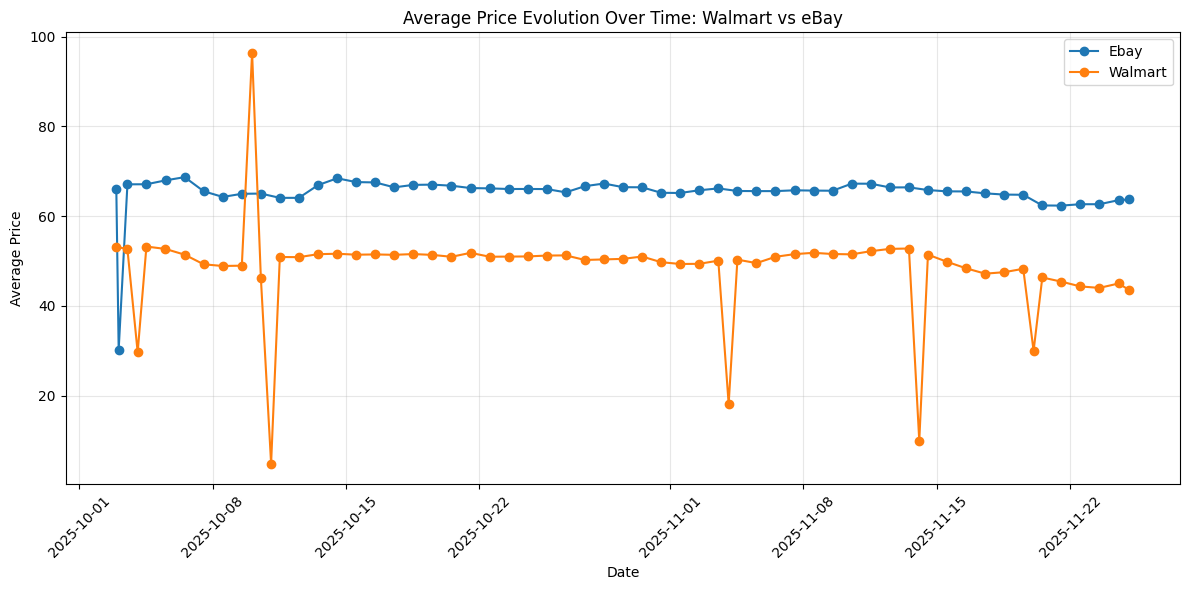

In [30]:
import matplotlib.pyplot as plt

# Ensure date format
df["captured_at"] = pd.to_datetime(df["captured_at"])

# Aggregate: average price per day per retailer
price_trend = (
    df.groupby(["retailer_id", "captured_at"])["price_current"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

for retailer in price_trend["retailer_id"].unique():
    subset = price_trend[price_trend["retailer_id"] == retailer]
    plt.plot(
        subset["captured_at"],
        subset["price_current"],
        marker="o",
        label=retailer.capitalize()
    )

plt.title("Average Price Evolution Over Time: Walmart vs eBay")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
